https://github.com/4GeeksAcademy/alternative-time-series-project/blob/main/solution.ipynb

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from imblearn.metrics import specificity_score
from scipy.stats import randint, uniform
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import pickle
import joblib
from sklearn.metrics import log_loss

In [49]:
# FUNCIONES
## Formato 5 decimales
pd.options.display.float_format = '{:,.5f}'.format 

## Metricas de clasificacion
def metricas_clas(y_train, y_test, y_pred_train, y_pred_test):
    # Calcular métricas para el conjunto de entrenamiento
    train_accuracy = accuracy_score(y_train, y_pred_train)
    train_f1 = f1_score(y_train, y_pred_train)
    train_precision = precision_score(y_train, y_pred_train)
    train_recall = recall_score(y_train, y_pred_train)
    train_specificity = specificity_score(y_train, y_pred_train)

    # Calcular métricas para el conjunto de prueba
    test_accuracy = accuracy_score(y_test, y_pred_test)
    test_f1 = f1_score(y_test, y_pred_test)
    test_precision = precision_score(y_test, y_pred_test)
    test_recall = recall_score(y_test, y_pred_test)
    test_specificity = specificity_score(y_test, y_pred_test)

    # Calcular la diferencia entre métricas de entrenamiento y prueba
    diff_accuracy = train_accuracy - test_accuracy
    diff_f1 = train_f1 - test_f1
    diff_precision = train_precision - test_precision
    diff_recall = train_recall - test_recall
    diff_specificity = train_specificity - test_specificity

    # Crear un DataFrame con los resultados
    metrics_df = pd.DataFrame([[train_accuracy,train_recall,train_specificity,train_precision,train_f1],
                               [test_accuracy, test_recall, test_specificity, test_precision,test_f1],
                               [diff_accuracy, diff_recall, diff_specificity, diff_precision, diff_f1]],
                              columns = ['Accuracy', 'Recall', 'Specificity', 'Precision', 'F1'],
                              index = ['Train','Test', 'Diferencia'])

    return metrics_df

# **0. CONTEXTO Y CARGA DATOS**

Mismo análisis que en ``04-decission-tree.ipynb``, pero aplicando el algoritmo ``Gradient Boosting``

In [50]:
# Cargamos la base de datos
df=pd.read_csv(("diabetes.csv")).drop(columns="Unnamed: 0")
#Hacemos train test split (mismo que en 04-decission-tree.ipynb)
X_train = df.iloc[:608].drop(columns=["Outcome"])
X_test = df.iloc[608:].drop(columns=["Outcome"])
y_train = df["Outcome"].iloc[:608]
y_test = df["Outcome"].iloc[608:]
#Comprobamos split
print(X_train.mean(), "\n","-"*50,"\n",X_test.mean())

FileNotFoundError: [Errno 2] No such file or directory: 'diabetes.csv'

# 1. Entrenamiento del modelo

In [ ]:
#Cargamos el rf optimizado
rf=joblib.load(open("RF.joblib", "rb"))
print(rf.get_params)

<bound method BaseEstimator.get_params of RandomForestClassifier(max_depth=17, min_samples_leaf=15, min_samples_split=73,
                       n_estimators=89, random_state=42)>


,0.02000,0.06000,0.10000,0.14000,0.18000
1,0.00000,0.00000,0.00000,0.00000,0.00000
2,0.00000,0.00000,0.00000,0.00000,0.31746
3,0.00000,0.00000,0.00000,0.31746,0.31746
4,0.00000,0.00000,0.31746,0.33333,0.42254
5,0.00000,0.00000,0.31746,0.42254,0.44444
...,...,...,...,...,...
146,0.57831,0.60674,0.61364,0.64444,0.60000
147,0.57831,0.60674,0.61364,0.64444,0.60000
148,0.57831,0.60674,0.61364,0.64444,0.60000
149,0.57831,0.60674,0.61364,0.64444,0.60000


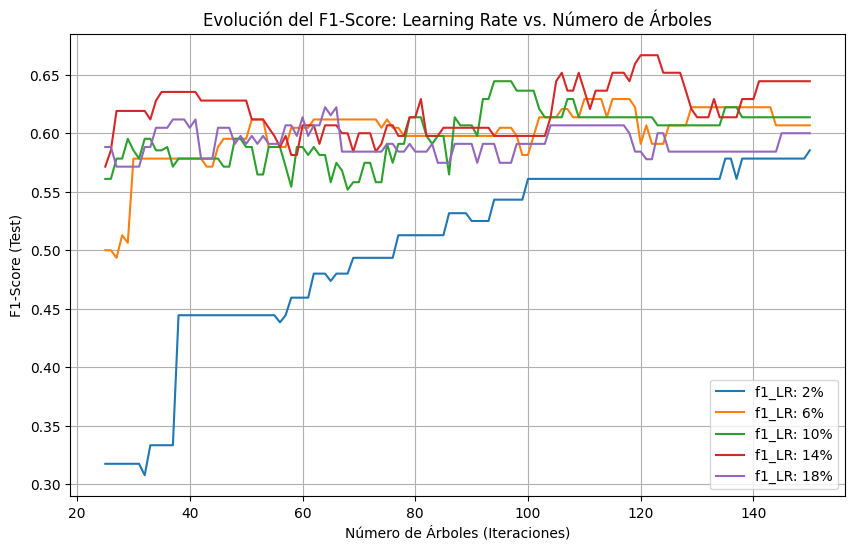

In [ ]:
#Dividimos train en entrena y val para evaluar diferentes configuraciones
X_entrena,X_val, y_entrena, y_val=train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Definimos el conjunto de valores posibles
plt.figure(figsize=(10, 6))

valores=[]

for lr in np.arange(0.02, 0.2 ,0.04):
    # 1. Configurar y entrenar el modelo
    gbc = GradientBoostingClassifier(n_estimators=150, learning_rate=lr, random_state=42)
    gbc.fit(X_entrena, y_entrena)
    
    # 2. Calcular el F1-score en cada "etapa" (staged) sobre el set de test
    f1_etapas = []
    for y_pred in gbc.staged_predict(X_val):
        f1_etapas.append(f1_score(y_val, y_pred))
    
    # 3. Guardamos los valores de F1 para cada lr
    valores.append(f1_etapas)

    # 4. Graficar la evolución para este learning rate
    plt.plot(range(25, 151), f1_etapas[24:], label=f'f1_LR: {round(lr*100)}%')

plt.title('Evolución del F1-Score: Learning Rate vs. Número de Árboles')
plt.xlabel('Número de Árboles (Iteraciones)')
plt.ylabel('F1-Score (Test)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#Definicion optimiza de los parámetros
param=pd.DataFrame(valores, columns=range(1, 151), index=np.arange(0.02, 0.2 ,0.04)).T
print(f'Entrenaremos {param.iloc[:,3].idxmax()} arboles con un {param.max().idxmax()} learning rate (f1_score={param.max().max()})')

0.02000   0.58537
0.06000   0.62921
0.10000   0.64444
0.14000   0.66667
0.18000   0.63415
dtype: float64

Graficamente, podemos observar como el modelo que tiene un mejor desempeño sería con un learning rate de 14% 

In [ ]:
gbc=GradientBoostingClassifier(learning_rate=0.14, n_estimators=129, random_state=42)
gbc.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=0.14, n_estimators=129,
                           random_state=42)

# 2. Evaluación del modelo

------------------------------------------------------------
GONFIGURACIÓN INICIAL
------------------------------------------------------------
            Accuracy  Recall  Specificity  Precision      F1
Train        0.97697 0.94907      0.99235    0.98558 0.96698
Test         0.78431 0.72549      0.81373    0.66071 0.69159
Diferencia   0.19266 0.22358      0.17862    0.32486 0.27539


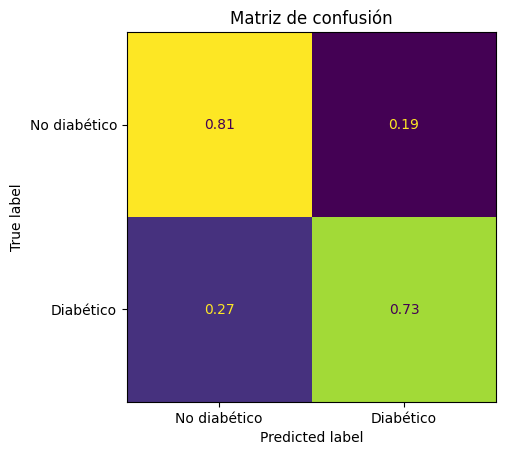

In [ ]:
#Predicciones
train_pred = gbc.predict(X_train)
test_pred = gbc.predict(X_test)
## Métricas
print("-"*60)
print("GONFIGURACIÓN INICIAL")
print("-"*60)
print(metricas_clas(y_train, y_test, train_pred, test_pred))

##Matriz de confusión
cm = confusion_matrix(y_test, test_pred, labels=[0, 1], normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["No diabético", "Diabético"])
disp.plot(cmap="viridis", colorbar=False)
plt.title("Matriz de confusión")
plt.show()

# 3. Optimización de hiperparámetros

In [ ]:
# Definimos hiperparámetros
param_grid = {
    'learning_rate': uniform(0.05,0.15),
    'loss': ["log_loss", "exponential"],
    'n_estimators': randint(50,150),
    'criterion': ["friedman_mse", "squared_error"],
    'max_depth': randint(2,23),
    'min_samples_leaf': randint(1,60),
    'min_samples_split': randint(2,120)} 

# Configurar GridSearchCV
random_search = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=20,
    scoring='recall',
    cv=5,
    verbose=4,
    n_jobs=-1,
    random_state=42,
)

# Ejecutamos la búsqueda 
random_search.fit(X_train, y_train)
print("Mejores hiperparámetros:")
print(random_search.best_params_)
random_mod = random_search.best_estimator_ #Guardamos los resultados

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejores hiperparámetros:
{'criterion': 'friedman_mse', 'learning_rate': np.float64(0.08881699724000254), 'loss': 'exponential', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 7, 'n_estimators': 103}


In [ ]:
#Comparación de métricas
## Métricas
print("-"*60)
print("MODELO SIN OPTIMIZAR")
print("-"*60)
print(metricas_clas(y_train, y_test, train_pred, test_pred))
## Métricas
print("-"*60)
print("MODELO OPTIMIZADO")
print("-"*60)
print(metricas_clas(y_train, y_test, random_search.predict(X_train), random_search.predict(X_test)))

------------------------------------------------------------
MODELO SIN OPTIMIZAR
------------------------------------------------------------
            Accuracy  Recall  Specificity  Precision      F1
Train        0.97697 0.94907      0.99235    0.98558 0.96698
Test         0.78431 0.72549      0.81373    0.66071 0.69159
Diferencia   0.19266 0.22358      0.17862    0.32486 0.27539
------------------------------------------------------------
MODELO OPTIMIZADO
------------------------------------------------------------
            Accuracy  Recall  Specificity  Precision      F1
Train        0.99836 1.00000      0.99745    0.99539 0.99769
Test         0.83007 0.76471      0.86275    0.73585 0.75000
Diferencia   0.16829 0.23529      0.13470    0.25954 0.24769


A través de la concreción obtenida por Random Search, se aprecia una mejora de efciciencia en el modelo entrenado, ya que este incrementa su precisión en 7 puntos porcentuales y su F1 score en 6 p.p. En términos de matriz de confusión, las predicciones quedarían como: 

[]

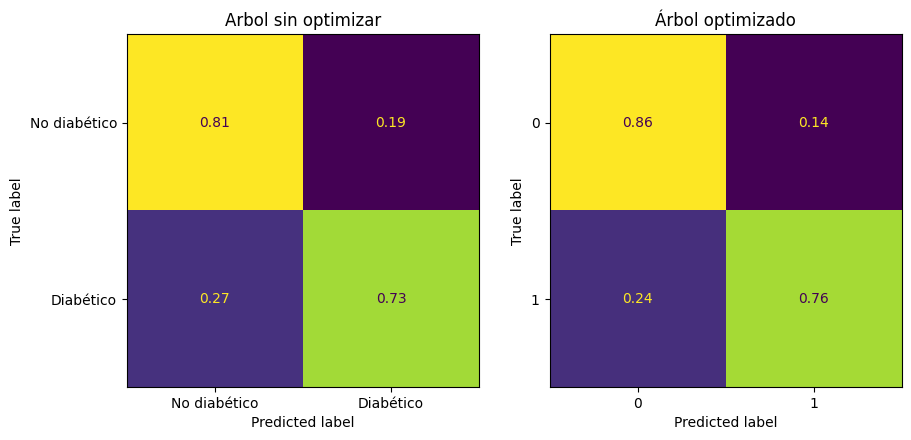

In [ ]:
#Matriz de confusión
## Sin Optimizar
cm1 = confusion_matrix(y_test, test_pred, normalize='true')
## Optimizado
cm2 = confusion_matrix(y_test, random_search.predict(X_test), normalize='true')

# Representación
fig, axis=plt.subplots(1,2, figsize=(10,5))
ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=["No diabético", "Diabético"]).plot(ax=axis[0],cmap='viridis',colorbar=False)
axis[0].set_title("Arbol sin optimizar")
ConfusionMatrixDisplay(confusion_matrix=cm2).plot(ax=axis[1],cmap='viridis', colorbar=False)
axis[1].set_title("Árbol optimizado")
plt.plot()

La mejora observada en la métricas se debe a que el modelo optimizado tiene un mejor desempeño en los falsos negativos, que representa un 3% del total de personas diabéticas.

# 4. Comparación de las metodologías

In [ ]:
#Cargamos los modelos y realizamos predicciones
arboles={"DecissionTree": pickle.load(open("DT.sav", "rb")),
         "RandomForest": rf,
         "GradientBoosting": random_mod}

pred={}
for x,mod in arboles.items():
    pred[f"{x}"]=[mod.predict(X_train),mod.predict(X_test)]

In [ ]:
for mod,yhat in pred.items():
    print("-"*60)
    print(f"{mod.upper()}")
    print("-"*60)
    print(metricas_clas(y_train, y_test, yhat[0], yhat[1]))

------------------------------------------------------------
DECISSIONTREE
------------------------------------------------------------
            Accuracy   Recall  Specificity  Precision      F1
Train        0.79770  0.75926      0.81888    0.69787 0.72727
Test         0.73203  0.76471      0.71569    0.57353 0.65546
Diferencia   0.06567 -0.00545      0.10319    0.12434 0.07181
------------------------------------------------------------
RANDOMFOREST
------------------------------------------------------------
            Accuracy   Recall  Specificity  Precision       F1
Train        0.78783  0.58796      0.89796    0.76048  0.66319
Test         0.81046  0.62745      0.90196    0.76190  0.68817
Diferencia  -0.02263 -0.03949     -0.00400   -0.00143 -0.02499
------------------------------------------------------------
GRADIENTBOOSTING
------------------------------------------------------------
            Accuracy  Recall  Specificity  Precision      F1
Train        0.99836 1.00000 

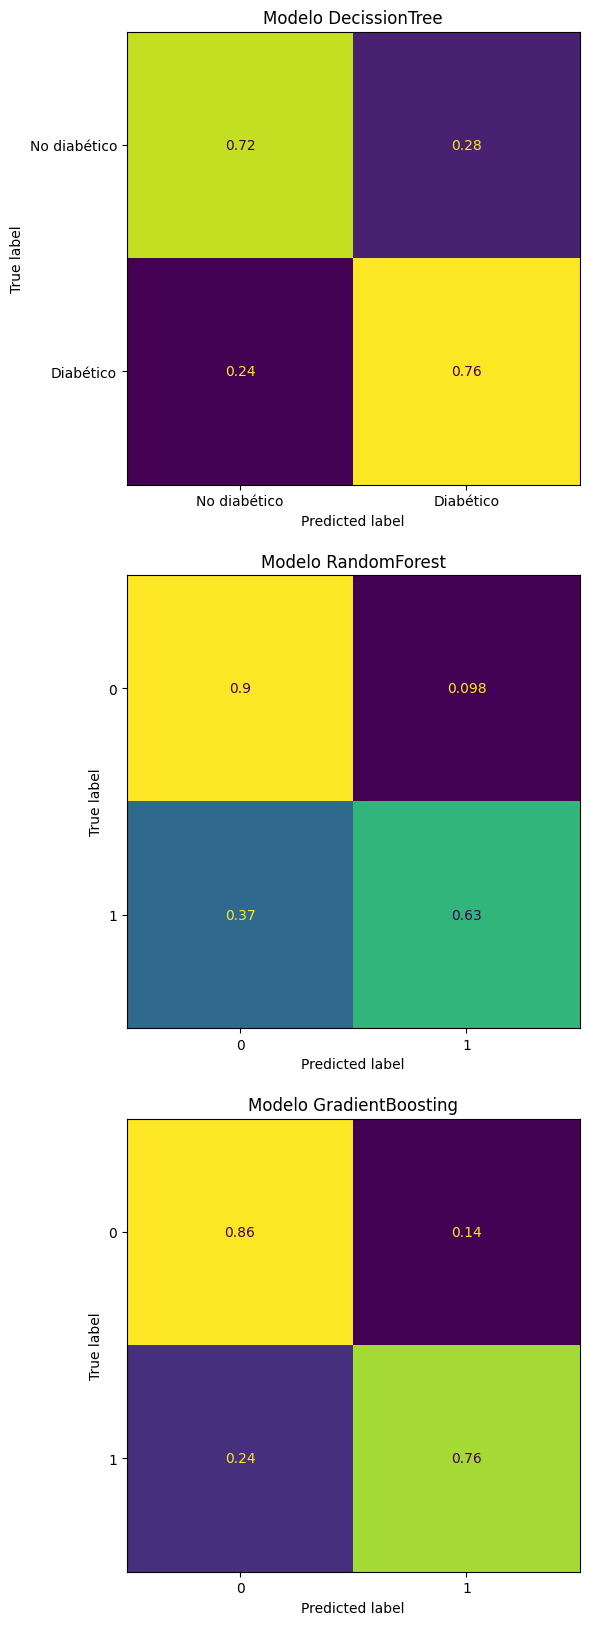

In [ ]:
#Matriz de confusión
cm={}

for mod,yhat in pred.items():
    cm[f"{mod}"]=confusion_matrix(y_test, yhat[1], normalize='true')
    
# Representación
fig, axis=plt.subplots(3, figsize=(10,20))
ConfusionMatrixDisplay(confusion_matrix=cm["DecissionTree"], display_labels=["No diabético", "Diabético"]).plot(ax=axis[0],cmap='viridis',colorbar=False)
axis[0].set_title("Modelo DecissionTree")
ConfusionMatrixDisplay(confusion_matrix=cm["RandomForest"]).plot(ax=axis[1],cmap='viridis', colorbar=False)
axis[1].set_title("Modelo RandomForest")
ConfusionMatrixDisplay(confusion_matrix=cm["GradientBoosting"]).plot(ax=axis[2],cmap='viridis', colorbar=False)
axis[2].set_title("Modelo GradientBoosting")
plt.show()

Por un lado, el modelo entrenado con Random Forest clasifica bastante bien a los individuos sin diabetes, arrojando una cifra de falsos positivos muy baja (1% del total de positivos). No obstante, su desempeño con los individuos afectados es bastante bajo ya que solo clasifica correctamente al 63% de los individuos con diabetes. 

Por otro lado, el modelo entrenado con Decision Tree obtiene estimaciones más genéricas para afectados y no afectados, aunque sus tasa de falsos positivos y negativos son bastante altas, en torno al 20% de cada categoría erróneamente clasificada.

Por último, el modelo que obtiene un mejor rendimeinto es el Gradient Boosting dado que mejora la cifra de especificidad en 14 p.p., mientras que reduce el número de falsos positivos a la mitad (14% del total de diabeticos).

In [ ]:
#Exportamos el modelo con joblib (más rápido que pickle)
joblib.dump(random_mod, "GB.joblib")